# Homework 6: Neural Networks
**Name:** Aragya Goyal | **Student ID:** 4541458 | **D value:** 58

In [22]:
# Import Packages
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

# Define Globals
D = 58

## Question 1: Conceptual Foundations

### Part A: Why Neural Networks?
A neural network can outperform logistic regression on a problem where the classes are not linearly seperable because of the hidden layers applying nonlinear activation functions to weighted combinations of input features. In homework #3, my one-vs-all model had a testing accuracy of 100%. This might have been because the classes were approximately linearly seperable with a small testing dataset. However, with a problem where classes are not linearly seperable, logistic regression would perform worse in comparison to a neural network due to the nonlinear activation functions of the neurons allowing it to model complex decision boundaries.

### Part B: The Sigmoid's Role
1. The dimensions of $\Theta$<sup>1</sup> are [3x5] and the dimensions for $\Theta$<sup>2</sup> will be [2x4]. I was able to derive this by drawing out the network as shown below. [TODO: ADD Image]

2. The sigmoid function at each unit is a non-linear activation function that puts the output into the range between 0 and 1. Within the hidden units, it is essentially creating new non-linear features for the forward layers. At the output units, it outputs a probability for classification. If you removed the sigmoid function from the hidden layer, then the units would just be linear functions of the inputs. And combining multiple linear functions on top of each other also just creates a linear function, therefore it would be exactly like logistic regression. Therefore, the neural network would not be powerful than logistic regression. The nonlinearity of the sigmoid function is what gives the neural network the characteristics it has and thus differentiates it from logistic regression.

### Part C: Forward vs. Backward
1. During forward propagation, the neural network takes the input features and passes them through each layer to compute a predicted output. Its purpose is to be able to make a prediction and is the typical manner in which a neural network is used. This is also used to determine how far a prediction is from the true label.
2. During backpropagation, we are able to calculate the blames on the weights and their contribution to the overall error. As we do this, we update the weights so that we can reduce the loss. This is done by calculating the gradients via the chain rule.
3. We cannot skip forward propagation and go directly to back propagation because backpropagation is dependent on the values predicted from forward propagation. Without these values, we cannot place blame on the weights during backpropagation and update them accordingly.

## Question 2: Building the Network Components
### Part A: Sigmoid and Sigmoid Gradient

In [23]:
# Implement sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Implement sigmoidGradient function
def sigmoidGradient(z):
    gz = sigmoid(z)
    return gz * (1 - gz)

# Verification of sigmoidGradient
z = np.array([-10, 0, 10])
print("Verification Test:")
print(sigmoidGradient(z.T), "\n")

# Text Output Test
z = np.array([-(D/5), 0, (D/5)])
print("Text Output:")
print(sigmoidGradient(z.T))

Verification Test:
[4.53958077e-05 2.50000000e-01 4.53958077e-05] 

Text Output:
[9.1659197e-06 2.5000000e-01 9.1659197e-06]


### Part B: Forward Propagation

In [24]:
# Implement forward propagation function
def predict(Theta1, Theta2, X):
    # Add bias column
    m = X.shape[0]
    bias = np.ones((m, 1))
    a1 = np.hstack([bias, X])

    # Compute hidden layer
    z2 = a1 @ Theta1.T
    a2 = sigmoid(z2)

    # Add bias column
    a2 = np.hstack([bias, a2])

    # Compute output layer hypothesis
    z3 = a2 @ Theta2.T
    h_x = sigmoid(z3)

    # Create prediction
    p = np.argmax(h_x, axis=1) + 1  # The outputs are 1-indexed
    
    return p, h_x

### Part C: Verification with Toy Data

In [25]:
# Set up toy data
Theta1_toy = np.array([[0.1 + D/1000, 0.2, -0.3],
                       [-0.1, 0.4 - D/1000, 0.1]])  # # shape: 2x3

Theta2_toy = np.array([[0.3, -0.2 + D/1000, 0.5],
                       [-0.4, 0.1, -0.3 + D/1000]]) # shape: 2x3

X_toy = np.array([[1, 0], [0, 1], [1, 1]])  # 3 samples

# Run prediction
p_toy, h_x_toy = predict(Theta1_toy, Theta2_toy, X_toy)

print(f"p_toy = {p_toy}")
print(f"h_x_toy = {h_x_toy}")

p_toy = [1 1 1]
h_x_toy = [[0.62164311 0.38302828]
 [0.61869965 0.38354129]
 [0.62697932 0.37988366]]


**Text Response:**

TODO: Do the pre-computation check and the written response

### Part D: Cost Function

In [26]:
# Implement the neural network cost function with regularization
def nnCost (Theta1, Theta2, X, y, K, lambda_val):
    # Recode y labels as one-hot vectors
    y_onehot = np.eye(K)[y - 1]

    # Use predict function
    p, h_x = predict(Theta1, Theta2, X)

    # Implement cost
    m = X.shape[0]
    J = ((-1/m) * np.sum(y_onehot * np.log(h_x) + (1 - y_onehot) * np.log(1 - h_x))) + ((lambda_val/(2*m)) * (np.sum(Theta1[:, 1:]**2) + np.sum(Theta2[:, 1:]**2))) 

    return J

# Verification with toy data
y_toy = np.array([1, 2, 1])
K_toy = len(np.unique(y_toy))
J_toy_0 = nnCost(Theta1_toy, Theta2_toy, X_toy, y_toy, K_toy, lambda_val=0)
J_toy_0_1 = nnCost(Theta1_toy, Theta2_toy, X_toy, y_toy, K_toy, lambda_val=0.1)

# Print out
print(f"J of toy dataset at lambda 0: {J_toy_0}")
print(f"J of toy dataset at lambda 0.1: {J_toy_0_1}")

J of toy dataset at lambda 0: 1.2751623310636833
J of toy dataset at lambda 0.1: 1.2850905310636833


**Text Response:**

The cost value I got with a lambda value of 0 was 1.2751623310636833 and the cost value I got with a lambda value of 0.1 was 1.2850905310636833. These do fall in the expected ranges. The regularized cost must always be greater than the unregularized cost because the regularization term always adds a non-negative value since it is a summation of the squared weights which can only maintain or increase the cost and never decrease it.

## Question 3: Backpropagation and Training
### Part A: Understanding Backpropagation

**Text Response:**

We do not compute the $\delta$ for the bias unit. This is because the bias unit always has a fixed activation of +1 regardless of the input. And since it has no upstream connection, there is also no error that can be propagated back. Because the bias term does not depend on any previous layer's outputs, there is no meaningful gradient to pass backward through it. If we did include it, we would compute a gradient for a unit that doesn't contribute to the chain of computations which would introduce an incorrect extra term into the weights update and distort the gradient computation.

### Part B: Implementing SGD with Backpropagation

In [27]:
# Implement the training function that learns network weights using backpropagation and stochastic gradient descent
def sGD(input_layer_size, hidden_layer_size, num_labels, X_train, y_train, lambda_val, alpha, MaxEpochs, random_seed=D):
    # Set the random seed
    np.random.seed(random_seed)

    # Initialize weights
    Theta1 = np.random.uniform(-0.15, 0.15, (hidden_layer_size, input_layer_size + 1))
    Theta2 = np.random.uniform(-0.15, 0.15, (num_labels, hidden_layer_size + 1))

    # Initialize cost_history
    cost_history = []

    # Get the number of training samples
    m = X_train.shape[0]

    # Set up y_onehot
    y_onehot = np.eye(num_labels)[y_train - 1]

    # Loop through epochs
    for epoch in range(MaxEpochs):
        for i in range(m):
            # Forward Pass (per sample)
            a1 = np.hstack([1, X_train[i]])
            z2 = a1 @ Theta1.T
            a2 = sigmoid(z2)
            a2 = np.hstack([1, a2])
            z3 = a2 @ Theta2.T
            a3 = sigmoid(z3)

            # Backward Pass (per sample)
            delta_3 = a3 - y_onehot[i]
            delta_2 = (Theta2.T @ delta_3) * sigmoidGradient(np.hstack([1, z2]))
            delta_2 = delta_2[1:]

            # Gradient with regularization
            grad2 = np.outer(delta_3, a2)
            grad2[:, 1:] += lambda_val * Theta2[:, 1:]
            grad1 = np.outer(delta_2, a1)
            grad1[:, 1:] += lambda_val * Theta1[:, 1:]

            # Weight update
            Theta2 = Theta2 - alpha * grad2
            Theta1 = Theta1 - alpha * grad1

        # Add cost after each epoch
        cost_history.append(nnCost(Theta1, Theta2, X_train, y_train, num_labels, lambda_val))
    
    # Return trained weights and cost_history
    return Theta1, Theta2, cost_history


### Part C: Verification on Toy Data

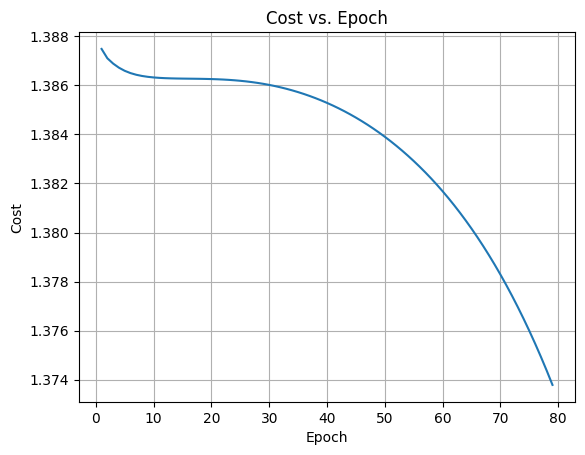

For D = 58
-----------
Final cost: 1.373780651936002
Training accuracy: 50.0%

For D = 59
-----------
Final cost: 1.3738562667712912
Training accuracy: 50.0%


In [28]:
# Define verification dataset
X_verify = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_verify = np.array([1, 2, 2, 1])

MaxEpochs = 50 + int(np.floor(D/2))

# Perform verification
Theta1_v, Theta2_v, cost_history_v = sGD(2, 4, 2, X_verify, y_verify, 0, 0.5, MaxEpochs, D)

# Plot the cost_history
plt.plot(range(1, len(cost_history_v) + 1), cost_history_v)
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.title('Cost vs. Epoch')
plt.grid()
plt.show()

# Calculate accuracy for D
p_v, h_x_v = predict(Theta1_v, Theta2_v, X_verify)
accuracy = np.mean(p_v == y_verify) * 100
print(f"For D = {D}")
print(f"-----------")
print(f"Final cost: {cost_history_v[-1]}")
print(f"Training accuracy: {accuracy}%\n")

# Perform verfication with D+1 seed
Theta1_v, Theta2_v, cost_history_v = sGD(2, 4, 2, X_verify, y_verify, 0, 0.5, MaxEpochs, D+1)
p_v, h_x_v = predict(Theta1_v, Theta2_v, X_verify)
accuracy = np.mean(p_v == y_verify) * 100
print(f"For D = {D+1}")
print(f"-----------")
print(f"Final cost: {cost_history_v[-1]}")
print(f"Training accuracy: {accuracy}%")

**Text Response:**

The cost does not really decrease. The final cost with the original random seed of 58 is 1.373780651936002 and the final training accuracy is only 50.0%. This is likely not 100% because the optimization fails and gets stuck in a local minima. Even after trying a different seed, the results do not really change. What this tells us is that the sGD easily gets trapped in a local minima based on the parameters we have set. We could possibly try new alpha, higher epochs, or more hidden units to potentially fix this issue.

## Question 4: Dataset A: Iris Classification
### Part A: Data Exploration and Pre-Trained Verification

H = 9
X shape: (150, 4)
y shape: (150,)
Class 1: 50 samples
Class 2: 50 samples
Class 3: 50 samples


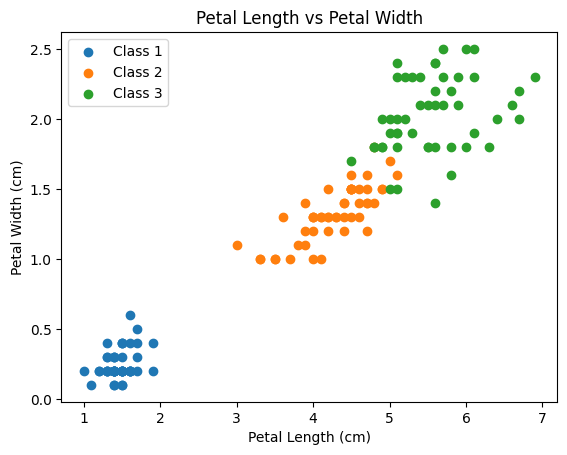

Accuracy: 98.0%
J(lambda=0): 0.20252633908551312
J(lambda=1): 1.0326189817073517
J(lambda=2): 1.8627116243291904


In [29]:
# Calculate H value
H = 5 + (D % 6)
print(f"H = {H}")

# Load the Dataset
iris_data = scipy.io.loadmat("./input/ps6_iris.mat")
X_iris = iris_data['X']
y_iris = iris_data['y'].flatten()

# Print dimensions of X and y
print(f"X shape: {X_iris.shape}")
print(f"y shape: {y_iris.shape}")

# Report samples per class
for c in np.unique(y_iris):
    print(f"Class {c}: {np.sum(y_iris == c)} samples")

# Create scatter plot
for c in np.unique(y_iris):
    plt.scatter(X_iris[y_iris == c, 2], X_iris[y_iris == c, 3], label=f'Class {c}')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()
plt.title('Petal Length vs Petal Width')
plt.show()

# Load weights
weights_iris = scipy.io.loadmat("./input/ps6_iris_weights.mat")
Theta1_iris = weights_iris['Theta1']
Theta2_iris = weights_iris['Theta2']

# Predict and compute accuracy
p_iris, h_x_iris = predict(Theta1_iris, Theta2_iris, X_iris)
accuracy = np.mean(p_iris == y_iris) * 100
print(f"Accuracy: {accuracy}%")

# Compute cost over different values of lambda
for lam in [0, 1, 2]:
    J_iris = nnCost(Theta1_iris, Theta2_iris, X_iris, y_iris, 3, lam)
    print(f"J(lambda={lam}): {J_iris}")

# TODO: Seeing really high values for lambda = 2 - needs checked

**Text Response:**

The accuracy is 98.0% and the three cost values are 0.203, 1.033, 1.863 for $\lambda$ = 0, 1, and 2 respectively. Based on the scatterplot, class 1 seems to be linearly seperable from the other two classes, since it is clustered on the bottom left with no overlap with other classes. However, classes 2 and 3 do seem to overlap.

### Part B: Train/Test Split

In [30]:
# Set Random Seed
np.random.seed(D)

# Randomize indices and calculate split
indices = np.random.permutation(X_iris.shape[0])
split = int(0.85 * X_iris.shape[0])

# Create the new training and testing split arrays
X_iris_train = X_iris[indices[:split]]
y_iris_train = y_iris[indices[:split]]
X_iris_test = X_iris[indices[split:]]
y_iris_test = y_iris[indices[split:]]

# Report training and testing samples
print(f"Training samples: {X_iris_train.shape[0]}")
print(f"Testing samples: {X_iris_test.shape[0]}")

Training samples: 127
Testing samples: 23


**Text Response:**

The split generates 127 training samples and 23 testing samples.

### Part C: Training and Evaluation

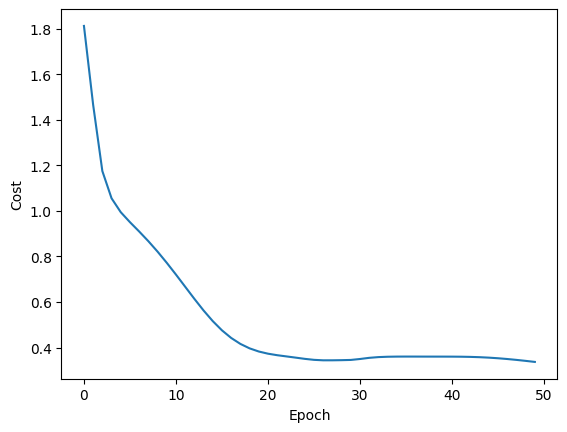

In [31]:
Theta1_t, Theta2_t, cost_hist = sGD(4, H, 3, X_iris_train, y_iris_train, 0, 0.05, 50, D)
plt.plot(cost_hist)
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.show()

**Choosing Alpha:**

TODO

lambda=0, epochs=50: training_accuracy=91.3%, test_accuracy=100.0%
lambda=0, epochs=100: training_accuracy=92.9%, test_accuracy=100.0%
lambda=0.01, epochs=50: training_accuracy=92.9%, test_accuracy=100.0%
lambda=0.01, epochs=100: training_accuracy=94.5%, test_accuracy=100.0%
lambda=0.1, epochs=50: training_accuracy=92.9%, test_accuracy=95.7%
lambda=0.1, epochs=100: training_accuracy=94.5%, test_accuracy=95.7%
lambda=1, epochs=50: training_accuracy=34.6%, test_accuracy=26.1%
lambda=1, epochs=100: training_accuracy=34.6%, test_accuracy=26.1%

Best config: lambda=0, epochs=50, test accuracy=100.0%


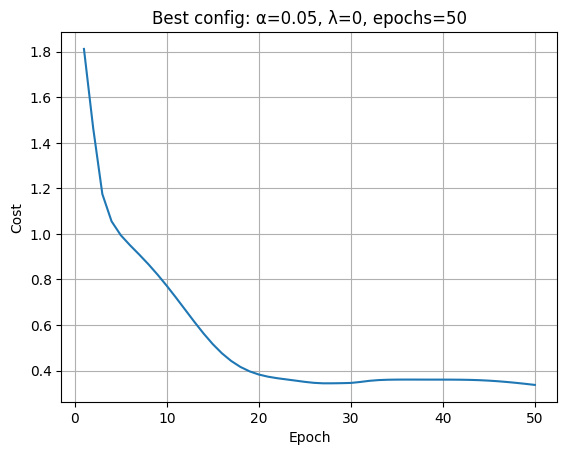

In [32]:
# Define parameters
alpha = 0.05
lambdas = [0, 0.01, 0.1, 1]
epochs_list = [50, 100]

# To store best config
test_best = 0
ch_best = []
lambda_best = 0
epochs_best = 0

# Do the training and testing and report
for lambda_val in lambdas:
    for epochs in epochs_list:
        T1, T2, ch = sGD(4, H, 3, X_iris_train, y_iris_train, lambda_val, alpha, epochs, D)
        
        p_train, _ = predict(T1, T2, X_iris_train)
        p_test, _ = predict(T1, T2, X_iris_test)
        
        train_acc = np.mean(p_train == y_iris_train) * 100
        test_acc = np.mean(p_test == y_iris_test) * 100
        
        print(f"lambda={lambda_val}, epochs={epochs}: training_accuracy={train_acc:.1f}%, test_accuracy={test_acc:.1f}%")

        if (test_acc > test_best):
            test_best = test_acc
            ch_best = ch
            lambda_best = lambda_val
            epochs_best = epochs

# Plot the best combo
print(f"\nBest config: lambda={lambda_best}, epochs={epochs_best}, test accuracy={test_best:.1f}%")

plt.plot(range(1, len(ch_best) + 1), ch_best)
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.title(f'Best config: α={alpha}, λ={lambda_best}, epochs={epochs_best}')
plt.grid()
plt.show()

**Text Response:**

TODO

## Question 5: Dataset B - Vehicle Image Classification
### Part A: Data Exploration

H = 48
X shape: (15000, 1024)
y shape: (15000,)
Class 1: 5000 samples
Class 2: 5000 samples
Class 3: 5000 samples


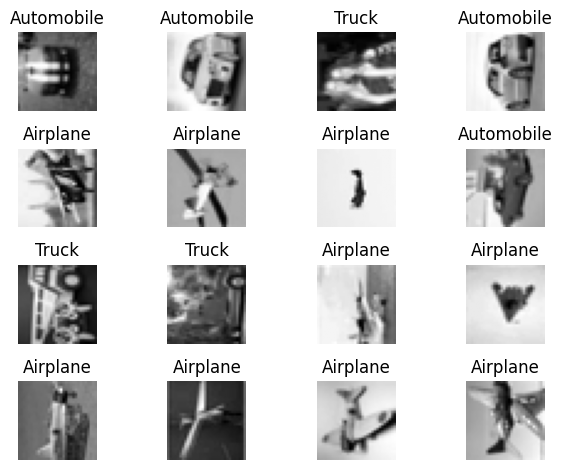

In [41]:
# Compute H
H_vehicles = 30 + (D % 20)
print(f"H = {H_vehicles}")

# Load dataset
data_v = scipy.io.loadmat('./input/ps6_vehicles.mat')
X_v = data_v['X']
y_v = data_v['y_labels'].flatten()

# Report dimensions
print(f"X shape: {X_v.shape}")
print(f"y shape: {y_v.shape}")

# Report number of samples per class
for c in np.unique(y_v):
    print(f"Class {c}: {np.sum(y_v == c)} samples")

# Display the 16 random images
class_names = {1: 'Airplane', 2: 'Automobile', 3: 'Truck'}
indices = np.random.choice(X_v.shape[0], 16, replace=False)

fig, axes = plt.subplots(4, 4)
for i, ax in enumerate(axes.flatten()):
    img = X_v[indices[i]].reshape(32, 32)
    ax.imshow(img, cmap='gray')
    ax.set_title(class_names[y_v[indices[i]]])
    ax.axis('off')

plt.tight_layout()
plt.show()